# 💰 Part 2: Price Estimation Model - Training & Saving

## Purpose
Train a Random Forest model to estimate repair costs.

## Output
- `price_model.pkl` - Trained price estimation model
- `price_scaler.pkl` - Feature scaler

---

In [1]:
# ============================================
# IMPORTS
# ============================================

print("="*80)
print("📦 LOADING LIBRARIES")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("\n✅ Libraries loaded!")
print("="*80)

📦 LOADING LIBRARIES

✅ Libraries loaded!


In [8]:
# ============================================
# CONFIGURATION
# ============================================

print("\n" + "="*80)
print("  CONFIGURATION")
print("="*80)

# Paths
DATA_DIR = Path('spare_parts_prices')
PRICE_CSV = DATA_DIR / 'toyota_sri_lanka_spare_parts_prices.csv'

# Output
OUTPUT_DIR = Path('models')
OUTPUT_DIR.mkdir(exist_ok=True)

PRICE_MODEL_PATH = OUTPUT_DIR / 'price_model.pkl'
PRICE_SCALER_PATH = OUTPUT_DIR / 'price_scaler.pkl'

# Hyperparameters
TEST_SIZE = 0.2
RANDOM_STATE = 42
N_ESTIMATORS = 100
MAX_DEPTH = 15

print(f"\n Data: {PRICE_CSV}")
print(f" Output: {OUTPUT_DIR}")
print(f" Estimators: {N_ESTIMATORS}")
print(f" Max depth: {MAX_DEPTH}")
print("\n Configuration complete!")
print("="*80)


  CONFIGURATION

 Data: spare_parts_prices/toyota_sri_lanka_spare_parts_prices.csv
 Output: models
 Estimators: 100
 Max depth: 15

 Configuration complete!


In [9]:
# ============================================
# LOAD & EXPLORE DATA
# ============================================

print("\n" + "="*80)
print("📂 LOADING PRICING DATA")
print("="*80)

# Load data
df = pd.read_csv(PRICE_CSV)

print(f"\n✅ Loaded {len(df)} pricing records")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSample data:")
print(df.head())

print(f"\n📊 Data Info:")
print(df.info())

print(f"\n📊 Statistics:")
print(df.describe())

print("="*80)


📂 LOADING PRICING DATA

✅ Loaded 819 pricing records

Columns: ['Brand', 'Model', 'Year', 'Part_Name', 'Price_LKR (Indicative)', 'Source (Market Listing Category)']

Sample data:
    Brand   Model  Year              Part_Name  Price_LKR (Indicative)   
0  toyota  allion  2007   Alloy Wheel (Single)                 41600.0  \
1  toyota  allion  2007  Brake Pad Set (Front)                 14300.0   
2  toyota  allion  2007            Fender (LH)                 26100.0   
3  toyota  allion  2007            Fender (RH)                 26100.0   
4  toyota  allion  2007           Front Bumper                 47500.0   

  Source (Market Listing Category)  
0              ikman.lk & daraz.lk  
1                         daraz.lk  
2                         ikman.lk  
3                         ikman.lk  
4                         ikman.lk  

📊 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 6 columns):
 #   Column                        

In [11]:
# ============================================
# DATA PREPROCESSING
# ============================================

print("\n" + "="*80)
print("🔄 DATA PREPROCESSING")
print("="*80)

# Remove outliers (IQR method)
print("\n🧹 Removing outliers...")
Q1 = df['Price_LKR (Indicative)'].quantile(0.25)
Q3 = df['Price_LKR (Indicative)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['Price_LKR (Indicative)'] >= lower_bound) & (df['Price_LKR (Indicative)'] <= upper_bound)].copy()

print(f"   Removed {len(df) - len(df_clean)} outliers")
print(f"   Remaining: {len(df_clean)} records")

# Feature engineering
print("\n🔧 Creating features...")

# Example: Calculate vehicle age
if 'year' in df_clean.columns:
    df_clean['vehicle_age'] = 2025 - df_clean['year']
    print("Created 'vehicle_age'")

# Encode categorical variables
categorical_cols = df_clean.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    if col != 'Price_LKR (Indicative)':  # Don't encode target
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded '{col}'")

# Select features (adjust based on your data)
# Example feature columns - modify based on your actual data
feature_columns = [col for col in df_clean.columns if col != 'Price_LKR (Indicative)']

X = df_clean[feature_columns]
y = df_clean['Price_LKR (Indicative)']

print(f"\n Features: {list(X.columns)}")
print(f" Target: Price_LKR (Indicative)")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\n Training set: {len(X_train)} samples")
print(f" Test set: {len(X_test)} samples")

# Scale features
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled!")
print("="*80)


🔄 DATA PREPROCESSING

🧹 Removing outliers...
   Removed 62 outliers
   Remaining: 757 records

🔧 Creating features...
Encoded 'Brand'
Encoded 'Model'
Encoded 'Part_Name'
Encoded 'Source (Market Listing Category)'

 Features: ['Brand', 'Model', 'Year', 'Part_Name', 'Source (Market Listing Category)']
 Target: Price_LKR (Indicative)

 Training set: 605 samples
 Test set: 152 samples

Scaling features...
 Features scaled!


In [12]:
# ============================================
# MODEL TRAINING
# ============================================

print("\n" + "="*80)
print("🎓 MODEL TRAINING")
print("="*80)

if PRICE_MODEL_PATH.exists():
    print("\n Model already exists!")
    print(f"   Path: {PRICE_MODEL_PATH}")
    print("\n Delete the file to retrain, or skip to evaluation.")
    
    model = joblib.load(PRICE_MODEL_PATH)
    scaler = joblib.load(PRICE_SCALER_PATH)
    print(" Model and scaler loaded!")
    
else:
    print("\n Training Random Forest model...\n")
    
    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Save model and scaler
    joblib.dump(model, PRICE_MODEL_PATH)
    joblib.dump(scaler, PRICE_SCALER_PATH)
    
    print("\n" + "="*80)
    print(" TRAINING COMPLETE!")
    print("="*80)
    print(f"\n Saved files:")
    print(f"   • {PRICE_MODEL_PATH}")
    print(f"   • {PRICE_SCALER_PATH}")

print("\n Model ready for evaluation!")


🎓 MODEL TRAINING

 Training Random Forest model...


 TRAINING COMPLETE!

 Saved files:
   • models/price_model.pkl
   • models/price_scaler.pkl

 Model ready for evaluation!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [13]:
# ============================================
# EVALUATION
# ============================================

print("\n" + "="*80)
print(" MODEL EVALUATION")
print("="*80)

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("\n Training Metrics:")
print(f"   R² Score: {train_r2:.4f}")

print("\n Test Metrics:")
print(f"   R² Score: {test_r2:.4f}")
print(f"   MAE: LKR {test_mae:,.2f}")
print(f"   RMSE: LKR {test_rmse:,.2f}")
print(f"   MAPE: {test_mape:.2f}%")

# Overfitting check
overfitting_gap = train_r2 - test_r2
print(f"\n🔍 Overfitting Check:")
print(f"   Train-Test Gap: {overfitting_gap:.4f}")
if overfitting_gap < 0.1:
    print("   Minimal overfitting")
elif overfitting_gap < 0.2:
    print("   Moderate overfitting")
else:
    print("   Significant overfitting")

print("="*80)


 MODEL EVALUATION

 Training Metrics:
   R² Score: 0.9815

 Test Metrics:
   R² Score: 0.9120
   MAE: LKR 5,833.00
   RMSE: LKR 10,713.89
   MAPE: 10.04%

🔍 Overfitting Check:
   Train-Test Gap: 0.0695
   Minimal overfitting


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished



 Creating visualizations...



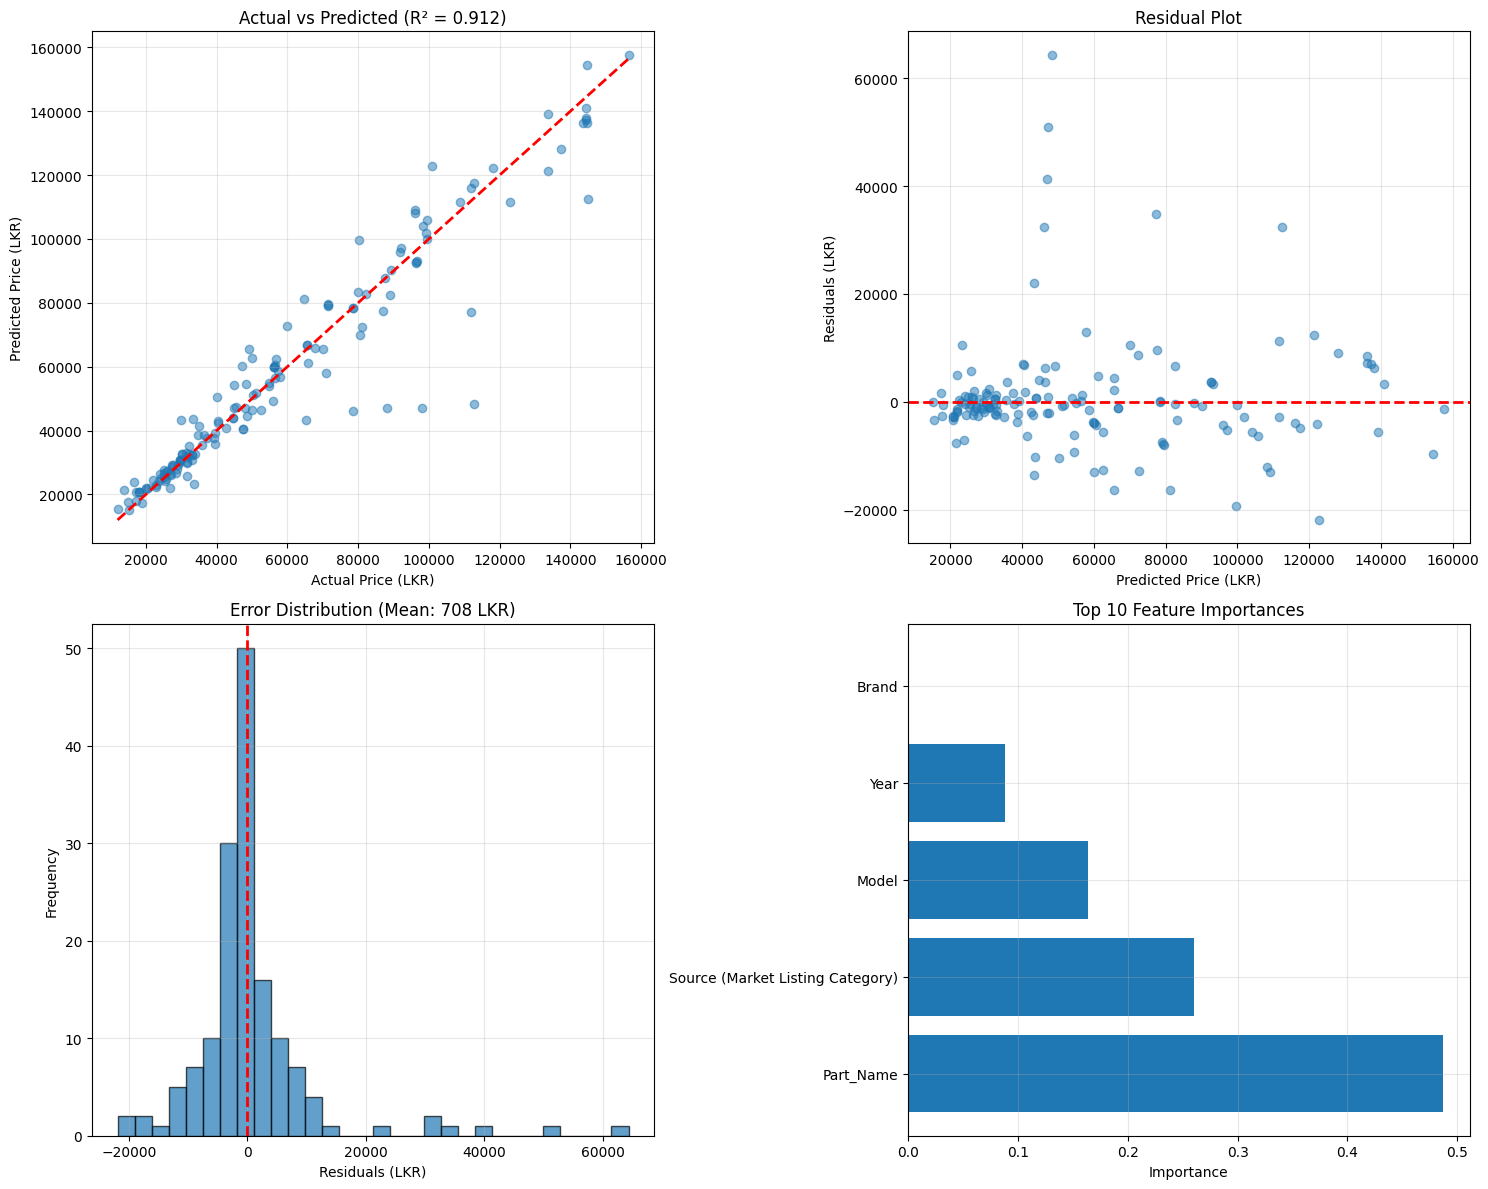

 Visualizations saved!

PRICE ESTIMATION MODEL READY FOR DEPLOYMENT!

 Model saved at: models/price_model.pkl


In [14]:
# ============================================
# VISUALIZATIONS
# ============================================

print("\n Creating visualizations...\n")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_test, y_test_pred, alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price (LKR)')
ax.set_ylabel('Predicted Price (LKR)')
ax.set_title(f'Actual vs Predicted (R² = {test_r2:.3f})')
ax.grid(True, alpha=0.3)

# 2. Residuals
ax = axes[0, 1]
residuals = y_test - y_test_pred
ax.scatter(y_test_pred, residuals, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Price (LKR)')
ax.set_ylabel('Residuals (LKR)')
ax.set_title('Residual Plot')
ax.grid(True, alpha=0.3)

# 3. Error distribution
ax = axes[1, 0]
ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Residuals (LKR)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean: {residuals.mean():.0f} LKR)')
ax.grid(True, alpha=0.3)

# 4. Feature importance
ax = axes[1, 1]
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # Top 10
ax.barh(range(len(indices)), importances[indices])
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_columns[i] for i in indices])
ax.set_xlabel('Importance')
ax.set_title('Top 10 Feature Importances')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'price_evaluation.png', dpi=150)
plt.show()

print(" Visualizations saved!")
print("\n" + "="*80)
print("PRICE ESTIMATION MODEL READY FOR DEPLOYMENT!")
print("="*80)
print(f"\n Model saved at: {PRICE_MODEL_PATH}")